# Data, Integrity & EDA


In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:

DATA_PATH = "/content/drive/MyDrive/GrainWise_Project_ML/Rice_Cammeo_Osmancik.arff"

import os
print("Exists:", os.path.exists(DATA_PATH))
if not os.path.exists(DATA_PATH):
    d = os.path.dirname(DATA_PATH)
    print("Files in that folder:", os.listdir(d) if os.path.isdir(d) else "folder not found")

Exists: True


In [ ]:
import numpy as np, pandas as pd, hashlib, datetime
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")
print("Run date:", datetime.date.today())

Run date: 2026-10-08


## Step 1 — Load

In [ ]:
EXPECTED = ["Area", "Perimeter", "Major_Axis_Length", "Minor_Axis_Length",
            "Eccentricity", "Convex_Area", "Extent", "Class"]

def load_raw(path):
    p = str(path).lower()
    if p.endswith(".arff"):
        cols, rows, in_data = [], [], False
        with open(path, "r", errors="ignore") as f:
            for line in f:
                s = line.strip()
                if not s or s.startswith("%"):
                    continue
                low = s.lower()
                if low.startswith("@attribute"):
                    cols.append(s.split()[1].strip("'\""))
                elif low.startswith("@data"):
                    in_data = True
                elif in_data:
                    rows.append([v.strip().strip("'\"") for v in s.split(",")])
        d = pd.DataFrame(rows, columns=cols)
    elif p.endswith((".xlsx", ".xls")):
        d = pd.read_excel(path)
    else:
        d = pd.read_csv(path)

    d.columns = [str(c).strip().replace(" ", "_") for c in d.columns]
    d = d.rename(columns={c: e for c in d.columns for e in EXPECTED
                          if c.lower() == e.lower()})
    missing = [c for c in EXPECTED if c not in d.columns]
    if missing:
        raise ValueError(f"Missing columns {missing}.\nFound: {list(d.columns)}")
    d = d[EXPECTED].copy()
    for c in EXPECTED[:-1]:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    d["Class"] = d["Class"].astype(str).str.strip().str.capitalize()
    return d

df = load_raw(DATA_PATH)
print("Class values found:", sorted(df["Class"].unique()))
assert set(df["Class"].unique()) == {"Cammeo", "Osmancik"}, "Unexpected class labels"
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
fingerprint = hashlib.sha256(
    pd.util.hash_pandas_object(df, index=False).values.tobytes()
).hexdigest()
print("\nSHA256 fingerprint:", fingerprint)
print("DOI: 10.24432/C5MW4Z   |   Downloaded:", datetime.date.today())
df.head()

Class values found: ['Cammeo', 'Osmancik']
Shape: (3810, 8)

Dtypes:
 Area                   int64
Perimeter            float64
Major_Axis_Length    float64
Minor_Axis_Length    float64
Eccentricity         float64
Convex_Area            int64
Extent               float64
Class                 object
dtype: object

SHA256 fingerprint: 34b654b9ced47786e52a1db77f8d58d53c05c54c7a8333b5182cb611678abbad
DOI: 10.24432/C5MW4Z   |   Downloaded: 2026-10-08


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231,525.578979,229.749878,85.093788,0.928882,15617,0.572896,Cammeo
1,14656,494.311005,206.020065,91.730972,0.895405,15072,0.615436,Cammeo
2,14634,501.122009,214.106781,87.768288,0.912118,14954,0.693259,Cammeo
3,13176,458.342987,193.337387,87.448395,0.891861,13368,0.640669,Cammeo
4,14688,507.166992,211.743378,89.312454,0.906691,15262,0.646024,Cammeo


## Step 2 — Integrity pass
Shape, missing values, duplicates, class counts.

In [ ]:
print("Missing values per column:")
print(df.isna().sum())

dups = df.duplicated().sum()
dups_features_only = df.drop(columns="Class").duplicated().sum()
print(f"\nExact duplicate rows (incl. Class): {dups}")
print(f"Duplicate feature rows (ignoring Class): {dups_features_only}")

print("\nClass counts:")
print(df["Class"].value_counts())
print("\nClass proportions:")
print(df["Class"].value_counts(normalize=True).round(4))

Missing values per column:
Area                 0
Perimeter            0
Major_Axis_Length    0
Minor_Axis_Length    0
Eccentricity         0
Convex_Area          0
Extent               0
Class                0
dtype: int64

Exact duplicate rows (incl. Class): 0
Duplicate feature rows (ignoring Class): 0

Class counts:
Class
Osmancik    2180
Cammeo      1630
Name: count, dtype: int64

Class proportions:
Class
Osmancik    0.5722
Cammeo      0.4278
Name: proportion, dtype: float64


## Step 3 — Derived ratio features
These are **row-wise arithmetic** — each value depends only on its own row, so no
information crosses between rows and computing them before the split cannot leak.


- `Aspect_Ratio` = Major / Minor axis
- `Roundness` = 4·π·Area / Perimeter²
- `Solidity` = Area / Convex_Area

All three are **dimensionless**, which matters: `Area` is in *pixels* and therefore
depends on camera distance and resolution. A model built on absolute pixel counts
will not transfer to a different imaging rig. These features address that.

In [ ]:
def add_ratio_features(d):
    d = d.copy()
    d["Aspect_Ratio"] = d["Major_Axis_Length"] / d["Minor_Axis_Length"]
    d["Roundness"]    = 4 * np.pi * d["Area"] / (d["Perimeter"] ** 2)
    d["Solidity"]     = d["Area"] / d["Convex_Area"]
    return d

df = add_ratio_features(df)
print("Derived feature summary:")
print(df[["Aspect_Ratio", "Roundness", "Solidity"]].describe().round(4))

Derived feature summary:
       Aspect_Ratio  Roundness   Solidity
count     3810.0000  3810.0000  3810.0000
mean         2.1908     0.7698     0.9781
std          0.1895     0.0330     0.0061
min          1.5893     0.6203     0.9263
25%          2.0459     0.7461     0.9743
50%          2.1843     0.7698     0.9788
75%          2.3229     0.7940     0.9828
max          3.1422     0.9027     0.9903


## Step 4a — Stratified split


In [ ]:
FEATURES = [c for c in df.columns if c != "Class"]
X = df[FEATURES]
y = (df["Class"] == "Cammeo").astype(int)   # Cammeo = 1 = positive (the premium variety)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape}   Test: {X_test.shape}")
print(f"Train class balance (Cammeo=1): {y_train.mean():.4f}")
print(f"Test  class balance (Cammeo=1): {y_test.mean():.4f}")

train = X_train.copy(); train["Class"] = y_train
del X_test, y_test
print("\nTest set sealed.")

Train: (3048, 10)   Test: (762, 10)
Train class balance (Cammeo=1): 0.4278
Test  class balance (Cammeo=1): 0.4278

Test set sealed.


## Step 4b — EDA on the training partition only

In [ ]:
print("Descriptive statistics (training set):")
display(X_train.describe().T.round(3))

Descriptive statistics (training set):


,count,mean,std,min,25%,50%,75%,max
Area,3048.0,12673.868,1723.811,7551.000,11390.000,12427.500,13960.250,18313.000
Perimeter,3048.0,454.344,35.405,359.100,426.583,448.621,483.644,548.446
Major_Axis_Length,3048.0,188.812,17.384,145.264,174.419,185.713,203.535,239.010
Minor_Axis_Length,3048.0,86.341,5.713,59.532,82.727,86.499,90.112,107.542
Eccentricity,3048.0,0.887,0.021,0.777,0.872,0.889,0.903,0.948
Convex_Area,3048.0,12958.786,1767.515,7723.000,11630.250,12706.500,14287.250,18724.000
Extent,3048.0,0.663,0.078,0.497,0.599,0.646,0.730,0.861
Aspect_Ratio,3048.0,2.191,0.190,1.589,2.045,2.184,2.322,3.142
Roundness,3048.0,0.770,0.033,0.634,0.746,0.770,0.794,0.903
Solidity,3048.0,0.978,0.006,0.946,0.974,0.979,0.983,0.990


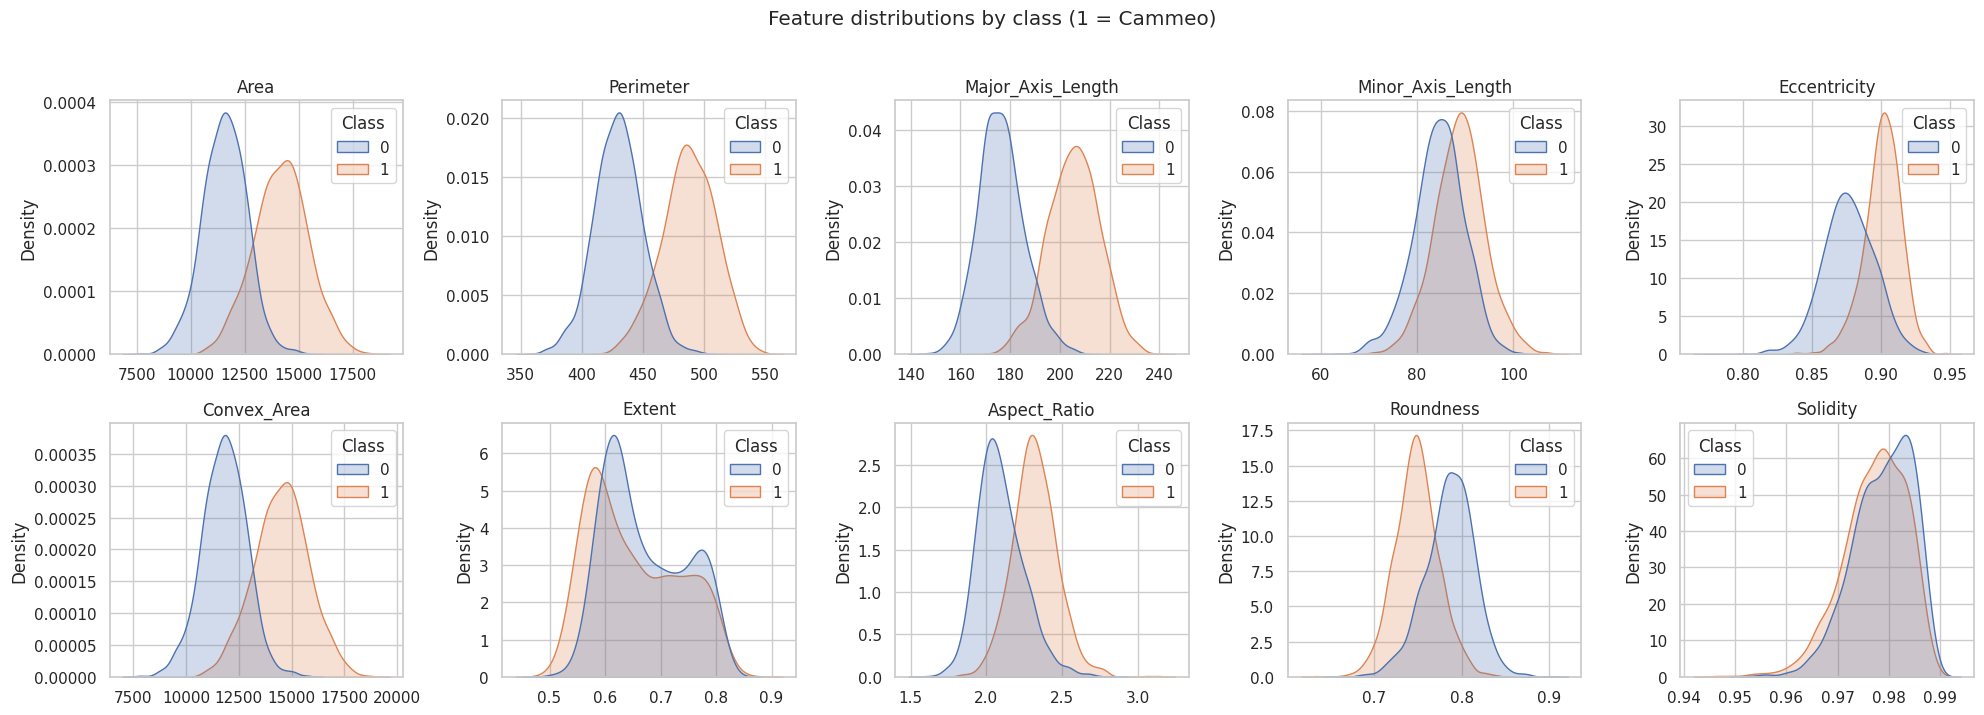

In [ ]:
ncols = 5
nrows = int(np.ceil(len(FEATURES) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, col in zip(axes, FEATURES):
    sns.kdeplot(data=train, x=col, hue="Class", fill=True, common_norm=False, ax=ax)
    ax.set_title(col); ax.set_xlabel("")
for ax in axes[len(FEATURES):]:
    ax.axis("off")
plt.suptitle("Feature distributions by class (1 = Cammeo)", y=1.02)
plt.tight_layout(); plt.show()

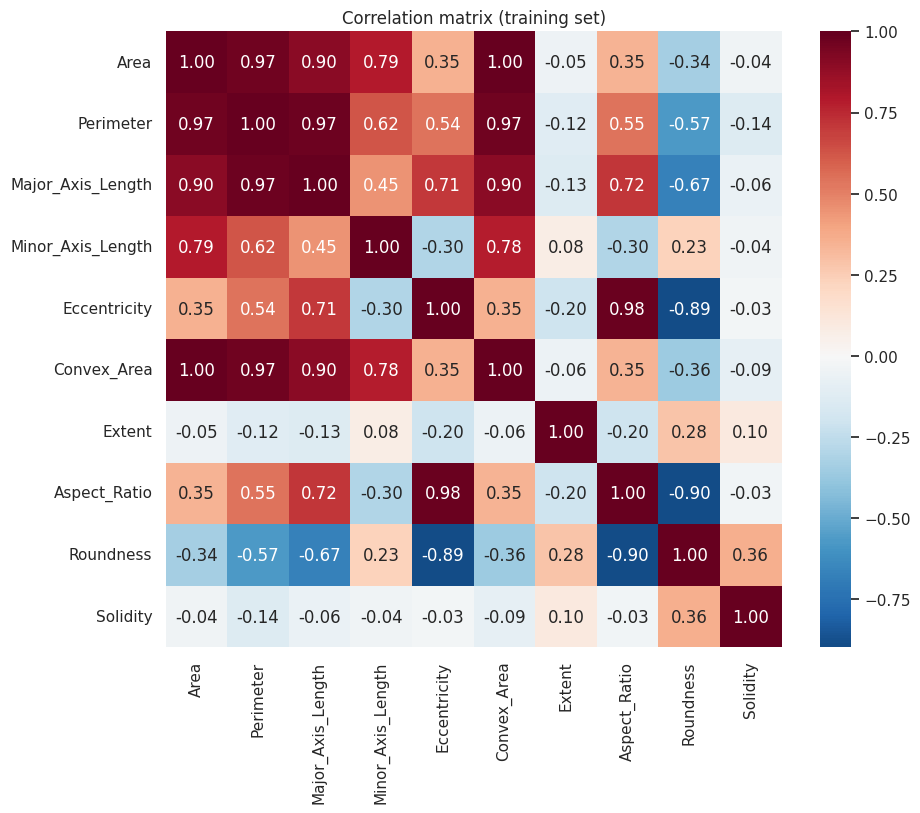

Feature pairs with |r| > 0.90:
               f1                f2        r
             Area       Convex_Area 0.998944
     Eccentricity      Aspect_Ratio 0.982819
        Perimeter Major_Axis_Length 0.971798
        Perimeter       Convex_Area 0.969440
             Area         Perimeter 0.966006
Major_Axis_Length       Convex_Area 0.902173
             Area Major_Axis_Length 0.901822


In [ ]:
corr = X_train.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Correlation matrix (training set)"); plt.show()

print("Feature pairs with |r| > 0.90:")
pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
             .stack().reset_index())
pairs.columns = ["f1", "f2", "r"]
print(pairs[pairs.r.abs() > 0.90].sort_values("r", key=abs, ascending=False)
           .to_string(index=False))

### Multicollinearity (VIF)
This is the main preprocessing decision on this dataset. Expect `Area`, `Convex_Area`,
`Perimeter` and `Major_Axis_Length` to be near-redundant size measures.

In [ ]:
!pip install statsmodels -q
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

Xs = pd.DataFrame(StandardScaler().fit_transform(X_train), columns=FEATURES)

def safe_vif(mat, i):
    # near-perfect collinearity makes the OLS fit singular; that IS the finding
    try:
        v = variance_inflation_factor(mat, i)
        return np.inf if not np.isfinite(v) else v
    except Exception:
        return np.inf

vif = pd.DataFrame({
    "feature": FEATURES,
    "VIF": [safe_vif(Xs.values, i) for i in range(len(FEATURES))]
}).sort_values("VIF", ascending=False)
print(vif.to_string(index=False, float_format=lambda v: f"{v:,.1f}"))
print("\nRule of thumb: VIF > 10 = serious multicollinearity; inf = perfectly redundant.")

          feature      VIF
      Convex_Area 32,541.4
             Area 30,901.8
        Perimeter  2,425.9
Major_Axis_Length  1,655.2
Minor_Axis_Length    315.6
     Aspect_Ratio    256.6
        Roundness    155.5
         Solidity     73.6
     Eccentricity     63.0
           Extent      1.1

Rule of thumb: VIF > 10 = serious multicollinearity; inf = perfectly redundant.


### Univariate separability
How much signal does each feature carry alone?

In [ ]:
from sklearn.metrics import roc_auc_score
sep = pd.DataFrame({
    "feature": FEATURES,
    "AUC": [max(roc_auc_score(y_train, X_train[c]), 1 - roc_auc_score(y_train, X_train[c]))
            for c in FEATURES]
}).sort_values("AUC", ascending=False)
print(sep.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

          feature    AUC
Major_Axis_Length 0.9788
        Perimeter 0.9720
      Convex_Area 0.9465
             Area 0.9447
     Eccentricity 0.8571
     Aspect_Ratio 0.8571
        Roundness 0.8427
Minor_Axis_Length 0.7199
           Extent 0.5823
         Solidity 0.5758


### Outlier scan


In [ ]:
q1, q3 = X_train.quantile(0.25), X_train.quantile(0.75)
iqr = q3 - q1
mask = ((X_train < (q1 - 1.5 * iqr)) | (X_train > (q3 + 1.5 * iqr)))
out = pd.DataFrame({"feature": FEATURES,
                    "n_outliers": mask.sum().values,
                    "pct": (100 * mask.mean()).round(2).values})
print(out.to_string(index=False))
print(f"\nRows flagged on >=1 feature: {mask.any(axis=1).sum()} "
      f"({100*mask.any(axis=1).mean():.2f}%)")

          feature  n_outliers  pct
             Area           3 0.10
        Perimeter           0 0.00
Major_Axis_Length           0 0.00
Minor_Axis_Length          52 1.71
     Eccentricity          19 0.62
      Convex_Area           2 0.07
           Extent           0 0.00
     Aspect_Ratio          15 0.49
        Roundness          13 0.43
         Solidity          30 0.98

Rows flagged on >=1 feature: 111 (3.64%)
